In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

In [3]:
data = {
    "business":[
        "Shop A",
        "Shop B",
        "Shop C",
        "Shop D",
        "Shop E",
    ],

"category": [
        "Retail",
        "Restaurant",
        "Pharmacy",
        "Retail",
        "Restaurant"
    ],
    "employees": [10, 8, 5, 15, 12],
    "latitude": [
        -33.9249,
        -33.9255,
        -33.9235,
        -33.9270,
        -33.9215
    ],
    "longitude": [
        18.4241,
        18.4260,
        18.4215,
        18.4290,
        18.4185
    ]
}

df = pd.DataFrame(data)

df

,business,category,employees,latitude,longitude
0,Shop A,Retail,10,-33.9249,18.4241
1,Shop B,Restaurant,8,-33.9255,18.4260
2,Shop C,Pharmacy,5,-33.9235,18.4215
3,Shop D,Retail,15,-33.9270,18.4290
4,Shop E,Restaurant,12,-33.9215,18.4185


In [6]:
geometry = [
Point(lon, lat)
    for lon, lat in zip(
        df["longitude"],
        df["latitude"]
    )
]

In [7]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=geometry,
    crs="EPSG:4326"
)

gpd

<module 'geopandas' from 'C:\\Users\\Ndlelenhle\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\geopandas\\__init__.py'>

In [8]:
len(gdf)

5

In [9]:
gdf["business"]

0    Shop A
1    Shop B
2    Shop C
3    Shop D
4    Shop E
Name: business, dtype: str

In [10]:
gdf["category"]

0        Retail
1    Restaurant
2      Pharmacy
3        Retail
4    Restaurant
Name: category, dtype: str

In [13]:
gdf[gdf["category"] == "retail"]

,business,category,employees,latitude,longitude,geometry


In [17]:
gdf.loc[gdf["employees"].idxmax()]

business                     Shop D
category                     Retail
employees                        15
latitude                    -33.927
longitude                    18.429
geometry     POINT (18.429 -33.927)
Name: 3, dtype: object

In [22]:
gdf[["business", "category", "geometry"]]

,business,category,geometry
0,Shop A,Retail,POINT (18.4241 -33.9249)
1,Shop B,Restaurant,POINT (18.426 -33.9255)
2,Shop C,Pharmacy,POINT (18.4215 -33.9235)
3,Shop D,Retail,POINT (18.429 -33.927)
4,Shop E,Restaurant,POINT (18.4185 -33.9215)


<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

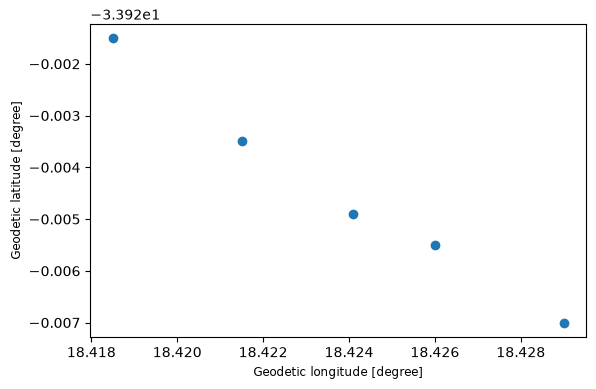

In [23]:
gdf.plot()

In [26]:
gdf_projected = gdf.to_crs("EPSG:3857")


In [27]:
shop_a = gdf_projected[gdf_projected["business"] == "Shop A"].geometry.iloc[0]

shop_b = gdf_projected[gdf_projected["business"] == "Shop B"].geometry.iloc[0]

shop_a.distance(shop_b)

226.3064157513591

In [28]:
gdf[gdf["employees"] > 10]

,business,category,employees,latitude,longitude,geometry
3,Shop D,Retail,15,-33.9270,18.4290,POINT (18.429 -33.927)
4,Shop E,Restaurant,12,-33.9215,18.4185,POINT (18.4185 -33.9215)
